In [1]:
pip install datasets evaluate gradio optuna transformers --quiet

In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
from nltk.translate.meteor_score import meteor_score
import evaluate
import optuna
from optuna import visualization as vis_optuna
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import random
import os
from google.colab import drive
import re

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Load all datasets
train_df = pd.read_csv('/content/drive/MyDrive/ET Final Project/train_df.csv')
val_df = pd.read_csv('/content/drive/MyDrive/ET Final Project/validation_df.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ET Final Project/test_df.csv')

# Rename and drop NAs consistently
for df in [train_df, val_df, test_df]:
    df.rename(columns={'Transcript': 'dialogue', 'Summary': 'summary'}, inplace=True)
    df.dropna(subset=['dialogue', 'summary'], inplace=True)

# Cleaner function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"\b[a-z]*\s?:", '', text)  # speaker labels
    text = re.sub(r"\?{2,}", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    text = re.sub(r"\s+", ' ', text)
    return text.strip()

# Clean all datasets
for df in [train_df, val_df, test_df]:
    df['dialogue'] = df['dialogue'].apply(clean_text)
    df['summary'] = df['summary'].apply(clean_text)

# 1000 sample for Optuna HPO
optuna_df = train_df.sample(n=1000, random_state=42)


In [6]:
# Set seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
# Tokenizer and preprocessing
tokenizer = T5Tokenizer.from_pretrained("t5-small")
max_input_length = 512
max_target_length = 128

def preprocess(example):
    inputs = tokenizer("summarize: " + example['dialogue'], max_length=max_input_length, padding="max_length", truncation=True)
    targets = tokenizer(example['summary'], max_length=max_target_length, padding="max_length", truncation=True)
    inputs["labels"] = targets["input_ids"]
    return inputs

optuna_dataset = Dataset.from_pandas(optuna_df).map(preprocess, batched=False)
train_val = optuna_dataset.train_test_split(test_size=0.2)

# Save full cleaned train_df for later
full_df = train_df

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [8]:
pip install rouge_score --quiet

In [9]:
# Metric functions
eval_rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):  # in case logits are returned
        preds = np.argmax(preds[0], axis=-1)

    preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = eval_rouge.compute(predictions=preds, references=labels, use_stemmer=True)
    result = {k: round(v, 4) for k, v in result.items()}
    meteor_scores = [meteor_score([l.split()], p.split()) for p, l in zip(preds, labels)]
    result['meteor'] = round(np.mean(meteor_scores), 4)
    return result

In [10]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
# Optuna objective function
def objective(trial):
    model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)

    training_args = TrainingArguments(
        output_dir=f"./results_{trial.number}",
        eval_strategy="epoch",
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        per_device_train_batch_size=trial.suggest_categorical("train_batch_size", [4, 8]),
        per_device_eval_batch_size=4,
        num_train_epochs=3,
        weight_decay=trial.suggest_float("weight_decay", 0.0, 0.3),
        logging_dir=f"./logs_{trial.number}",
        save_strategy="epoch",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_val['train'],
        eval_dataset=train_val['test'],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_result = trainer.evaluate()

    # Safe access to metric
    for key in eval_result:
        print(key, ":", eval_result[key])
    return eval_result.get("rougeL", eval_result.get("eval_rougeL", 0.0))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=3)

[I 2025-04-16 01:25:37,014] A new study created in memory with name: no-name-ae8d94bd-f5fd-4552-a12b-764208827428
<ipython-input-11-a6769a1b07c5>:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Meteor
1,No log,1.352311,0.643900,0.430500,0.589900,0.590800,0.542000
2,No log,1.251304,0.660800,0.449300,0.608700,0.609800,0.565100
3,No log,1.229816,0.668000,0.458300,0.616400,0.618000,0.576100


[I 2025-04-16 01:27:26,567] Trial 0 finished with value: 0.6164 and parameters: {'learning_rate': 0.0001232171363297947, 'train_batch_size': 8, 'weight_decay': 0.09756138104065161}. Best is trial 0 with value: 0.6164.


eval_loss : 1.22981595993042
eval_rouge1 : 0.668
eval_rouge2 : 0.4583
eval_rougeL : 0.6164
eval_rougeLsum : 0.618
eval_meteor : 0.5761
eval_runtime : 10.0537
eval_samples_per_second : 19.893
eval_steps_per_second : 4.973
epoch : 3.0


<ipython-input-11-a6769a1b07c5>:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

eval_loss : 1.3336386680603027
eval_rouge1 : 0.6428
eval_rouge2 : 0.4298
eval_rougeL : 0.5902
eval_rougeLsum : 0.5912
eval_meteor : 0.5429
eval_runtime : 9.9585
eval_samples_per_second : 20.083
eval_steps_per_second : 5.021
epoch : 3.0


<ipython-input-11-a6769a1b07c5>:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Meteor
1,No log,1.293417,0.650700,0.440900,0.599700,0.600600,0.553100
2,No log,1.198935,0.671600,0.464500,0.621800,0.622600,0.581500
3,No log,1.180371,0.676800,0.472700,0.627700,0.628400,0.590400


[I 2025-04-16 01:31:06,440] Trial 2 finished with value: 0.6277 and parameters: {'learning_rate': 0.0001740471064716766, 'train_batch_size': 8, 'weight_decay': 0.04646286731632945}. Best is trial 2 with value: 0.6277.


eval_loss : 1.1803712844848633
eval_rouge1 : 0.6768
eval_rouge2 : 0.4727
eval_rougeL : 0.6277
eval_rougeLsum : 0.6284
eval_meteor : 0.5904
eval_runtime : 9.8787
eval_samples_per_second : 20.246
eval_steps_per_second : 5.061
epoch : 3.0


In [12]:
#!pip install -U kaleido --quiet

In [13]:
# Log best trial and importances
best_trial = study.best_trial
print("Best trial:")
for k, v in best_trial.params.items():
    print(f"  {k}: {v}")

# Plot importance
fig_imp = vis_optuna.plot_param_importances(study)
fig_imp.show()


Best trial:
  learning_rate: 0.0001740471064716766
  train_batch_size: 8
  weight_decay: 0.04646286731632945


In [17]:
# Sample 50% of the cleaned full_df
sampled_df = full_df.sample(frac=0.5, random_state=42)

# Tokenize and preprocess
sampled_dataset = Dataset.from_pandas(sampled_df)
sampled_dataset = sampled_dataset.map(preprocess, batched=False)

# Train/Validation Split
train_val = sampled_dataset.train_test_split(test_size=0.2)

# Clear memory from Optuna runs before final model
import gc, torch
try: del model
except: pass
try: del trainer
except: pass
torch.cuda.empty_cache()
gc.collect()

# Load final model with Optuna best hyperparameters
final_model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
final_model.gradient_checkpointing_enable()  # saves memory

final_args = TrainingArguments(
    output_dir="./final_results",
    eval_strategy="epoch",
    learning_rate=best_trial.params['learning_rate'],
    per_device_train_batch_size=best_trial.params['train_batch_size'],
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=best_trial.params['weight_decay'],
    logging_dir="./final_logs",
    logging_steps=10,
    save_strategy="epoch",
    report_to="none"
)

#Train on 50% of the dataset
final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_val['train'],
    eval_dataset=train_val['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

final_trainer.train()
metrics = final_trainer.evaluate()
print("Final Evaluation Metrics on Sampled Dataset:", metrics)


Map:   0%|          | 0/2584 [00:00<?, ? examples/s]

<ipython-input-17-3f92a2a75a26>:39: FutureWarning:

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.



Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Meteor
1,1.321100,1.067110,0.710700,0.526400,0.670400,0.670100,0.634700
2,1.311200,0.987103,0.731100,0.553500,0.693100,0.692600,0.661600
3,1.127400,0.971566,0.734600,0.558500,0.697500,0.697100,0.666600


Final Evaluation Metrics on Sampled Dataset: {'eval_loss': 0.9715664386749268, 'eval_rouge1': 0.7346, 'eval_rouge2': 0.5585, 'eval_rougeL': 0.6975, 'eval_rougeLsum': 0.6971, 'eval_meteor': 0.6666, 'eval_runtime': 28.9535, 'eval_samples_per_second': 17.856, 'eval_steps_per_second': 4.49, 'epoch': 3.0}


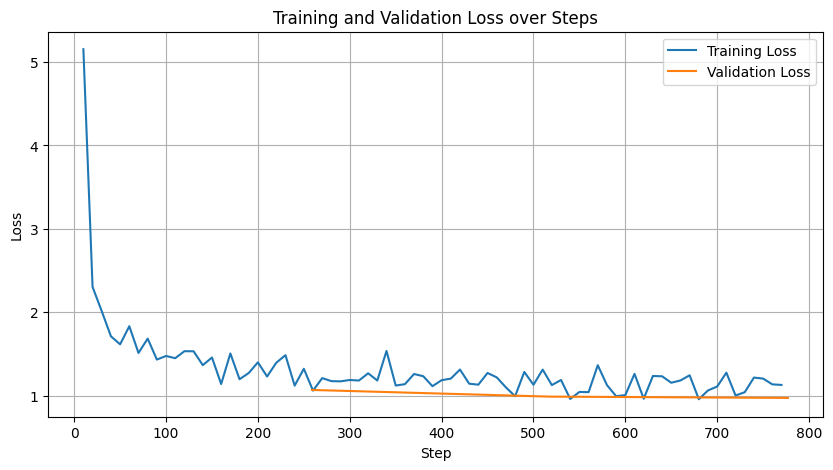

In [18]:
# Visualization - Training and Validation Loss
logs = pd.DataFrame(final_trainer.state.log_history)
plt.figure(figsize=(10, 5))
sns.lineplot(data=logs[logs["loss"].notnull()], x="step", y="loss", label="Training Loss")
if "eval_loss" in logs.columns or "eval_loss" in logs.dropna(axis=1).columns:
    sns.lineplot(data=logs[logs["eval_loss"].notnull()], x="step", y="eval_loss", label="Validation Loss")
plt.title("Training and Validation Loss over Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("training_validation_loss.png")
plt.show()

In [19]:
print("Available metric keys:", metrics.keys())
print("Full metrics:", metrics)

Available metric keys: dict_keys(['eval_loss', 'eval_rouge1', 'eval_rouge2', 'eval_rougeL', 'eval_rougeLsum', 'eval_meteor', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'epoch'])
Full metrics: {'eval_loss': 0.9715664386749268, 'eval_rouge1': 0.7346, 'eval_rouge2': 0.5585, 'eval_rougeL': 0.6975, 'eval_rougeLsum': 0.6971, 'eval_meteor': 0.6666, 'eval_runtime': 28.9535, 'eval_samples_per_second': 17.856, 'eval_steps_per_second': 4.49, 'epoch': 3.0}


<ipython-input-20-fbe083b32b5c>:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




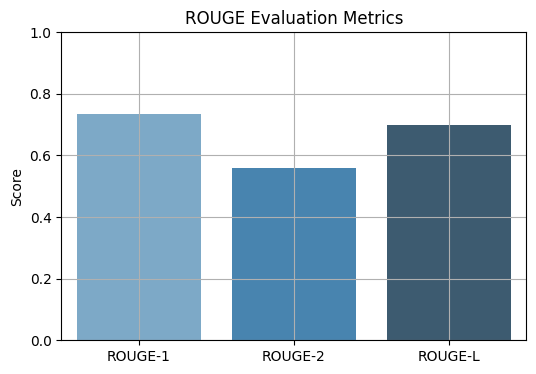

In [20]:
# ROUGE bar chart
rouge_keys = ['eval_rouge1', 'eval_rouge2', 'eval_rougeL']
rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
rouge_values = [metrics.get(k, 0.0) for k in rouge_keys]

plt.figure(figsize=(6, 4))
sns.barplot(x=rouge_labels, y=rouge_values, palette="Blues_d")
plt.title("ROUGE Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.savefig("rouge_scores.png")
plt.show()

<ipython-input-21-7a7866155e0d>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




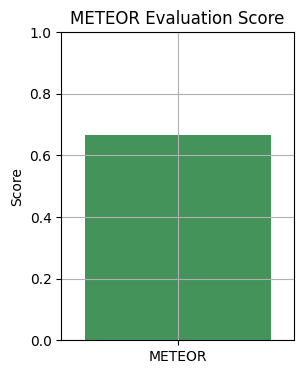

In [21]:
# METEOR bar chart
meteor_value = metrics.get('eval_meteor', 0.0)

plt.figure(figsize=(3, 4))
sns.barplot(x=['METEOR'], y=[meteor_value], palette="Greens_d")
plt.title("METEOR Evaluation Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.savefig("meteor_score.png")
plt.show()


In [22]:
# Gradio Interface
def generate_summary(text):
    input_ids = tokenizer("summarize: " + text, return_tensors="pt", truncation=True, padding="max_length", max_length=max_input_length).input_ids.to(device)
    output = final_model.generate(input_ids, max_length=max_target_length, num_beams=4, early_stopping=True)
    return tokenizer.decode(output[0], skip_special_tokens=True)

demo = gr.Interface(fn=generate_summary,
                    inputs=gr.Textbox(lines=15, label="Meeting Transcript"),
                    outputs=gr.Textbox(lines=5, label="Summary"),
                    title="T5 Meeting Transcript Summarizer with Optuna Tuning")

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9df72a8175d5a7810.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [31]:
# Test an example in this notebook not on gradio
import textwrap

def generate_summary(text, model, tokenizer, max_length=150):
    input_text = "summarize: " + text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=max_input_length, truncation=True).to(device)
    outputs = model.generate(inputs.input_ids, max_length=max_length, num_beams=4, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)
import textwrap

if 'dialogue' not in test_df.columns:
    test_df = test_df[['Transcript', 'Summary']].rename(columns={'Transcript': 'dialogue', 'Summary': 'summary'})
    test_df = test_df.dropna()

sample_transcript = test_df["dialogue"].iloc[20]
sample_summary = test_df["summary"].iloc[20]

generated_summary = generate_summary(sample_transcript, final_model, tokenizer)

# Wrap both summaries to make them into multiple lines instead of one long one
wrapped_ref = textwrap.fill(sample_summary, width=120)
wrapped_gen = textwrap.fill(generated_summary, width=120)

print("Reference Summary:\n")
print(wrapped_ref)
print("\nGenerated Summary:\n")
print(wrapped_gen)

Reference Summary:

a proclamation acknowledging the indian arts and crafts act of and the american indian arts and crafts symposium in
denver a proclamation acknowledging the indian arts and crafts act of and the american indian arts and crafts symposium
in denver

Generated Summary:

a proclamation acknowledging the indian arts and crafts act of and the american indian arts and crafts symposium in
denver


In [30]:
# Test an example in this notebook not on gradio
import textwrap

def generate_summary(text, model, tokenizer, max_length=150):
    input_text = "summarize: " + text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=max_input_length, truncation=True).to(device)
    outputs = model.generate(inputs.input_ids, max_length=max_length, num_beams=4, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

sample_transcript = test_df["dialogue"].iloc[10]
sample_summary = test_df["summary"].iloc[10]

generated_summary = generate_summary(sample_transcript, final_model, tokenizer)

# Wrap both summaries to make them into multiple lines instead of one long one
wrapped_ref = textwrap.fill(sample_summary, width=120)
wrapped_gen = textwrap.fill(generated_summary, width=120)

print("Reference Summary:\n")
print(wrapped_ref)
print("\nGenerated Summary:\n")
print(wrapped_gen)

Reference Summary:

recommendation to receive supporting documentation into the record conclude the public hearing and adopt resolution
amending the master fee and charges schedule citywide

Generated Summary:

recommendation to receive supporting documentation into the record conclude the public hearing and adopt resolution
amending the master fee and charges schedule


In [29]:
# Test an example in this notebook not on gradio
import textwrap

def generate_summary(text, model, tokenizer, max_length=150):
    input_text = "summarize: " + text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=max_input_length, truncation=True).to(device)
    outputs = model.generate(inputs.input_ids, max_length=max_length, num_beams=4, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

sample_transcript = test_df["dialogue"].iloc[3]
sample_summary = test_df["summary"].iloc[3]

generated_summary = generate_summary(sample_transcript, final_model, tokenizer)

# Wrap both summaries to make them into multiple lines instead of one long one
wrapped_ref = textwrap.fill(sample_summary, width=120)
wrapped_gen = textwrap.fill(generated_summary, width=120)

print("Reference Summary:\n")
print(wrapped_ref)
print("\nGenerated Summary:\n")
print(wrapped_gen)

Reference Summary:

recommendation to request city manager to direct airport director to provide a report on how the city of long beach will
participate in discussions with the faa to reduce helicopter noise

Generated Summary:

recommendation to request city manager to direct the airport director to provide a report on how the city of long beach
will participate in discussions with the faa to reduce helicopter noise
